# Training Results Visualization

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

## Setting

In [23]:
model = 'llama3-1b'
task = 'tydiqa'  # sociology, abstract_algebra, machine_learning, marketing, professional_law, tydiqa, and samsum

out_dir = "/scratch/pbb/Project/Efficient-Fine-Tuning"
# Configuration for each experiment type on each task
# Format: task -> method_type -> (batch_size, dataset_percentage, n_val, lr, seed, training_type)
experiment_configs = {
    # TydiQA experiments
    'tydiqa': {
        'Regular': (8, 0.1, 5, '3e-05', 42, 'full'),
        'LoRA': (8, 0.1, 5, '1e-04', 42, 'lora'),
        'MeSO (GraSS)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'MeSO (LoGra)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'GREATS (GraSS)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'GREATS (LoGra)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 5, '3e-05', 42, 'full'),
        'GREATS+LoRA (GraSS)': (8, 0.1, 5, '1e-04', 42, 'lora'),
        'GREATS+LoRA (LoGra)': (8, 0.1, 5, '1e-04', 42, 'lora'),
    },

    # SAMSUM experiments
    'samsum': {
        'Regular': (8, 0.5, 16, '5e-08', 3, 'full'),
        'LoRA': (8, 1.0, 16, '5e-05', 3, 'lora'),
        'MeSO (GraSS)': (8, 1.0, 16, '1e-06', 3, 'full'),
        'MeSO (LoGra)': (8, 1.0, 16, '1e-06', 3, 'full'),
        'GREATS+LoRA (GraSS)': (8, 1.0, 16, '5e-05', 3, 'lora'),
        'GREATS (LoGra)': (8, 0.5, 16, '1e-07', 3, 'full'),
        'GREATS+MeSO (LoGra)': (8, 0.5, 16, '5e-08', 3, 'full'),


        'GREATS (GraSS)': (8, 0.5, 16, '5e-08', 3, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.5, 16, '5e-08', 3, 'full'),
        'GREATS+LoRA (LoGra)': (8, 1.0, 16, '5e-05', 3, 'lora'),
    },

    # MMLU Sociology experiments
    'sociology': {
        'Regular': (8, 0.1, 8, '5e-05', 42, 'full'),
        'Regular LoRA': (8, 0.1, 8, '5e-05', 42, 'lora'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 8, '5e-05', 42, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 8, '5e-05', 42, 'full'),
        'GREATS (GraSS) LoRA': (8, 0.1, 8, '5e-05', 42, 'lora'),
        'GREATS (LoGra) LoRA': (8, 0.1, 8, '5e-05', 42, 'lora'),
    },

    # MMLU Abstract Algebra experiments
    'abstract_algebra': {
        'Regular': (8, 0.1, 5, '5e-05', 3, 'full'),
        'Regular LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS (GraSS) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS (LoGra) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
    },

    # MMLU Machine Learning experiments
    'machine_learning': {
        'Regular': (8, 0.1, 5, '5e-05', 3, 'full'),
        'Regular LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS (GraSS) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS (LoGra) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
    },

    # MMLU Marketing experiments
    'marketing' : {
        'Regular': (8, 0.1, 5, '5e-05', 3, 'full'),
        'Regular LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS (GraSS) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS (LoGra) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
    },

    # MMLU Professional Law experiments
    'professional_law': {
        'Regular': (8, 0.1, 5, '5e-05', 3, 'full'),
        'Regular LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS+MeSO (LoGra)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS+MeSO (GraSS)': (8, 0.1, 5, '5e-05', 3, 'full'),
        'GREATS (GraSS) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
        'GREATS (LoGra) LoRA': (8, 0.1, 5, '5e-05', 3, 'lora'),
    },
}

## Load Results

In [24]:
def load_results(result_path):
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]
    wall_time = [item.get('wall_time', None) for item in data]  # Use .get() for backward compatibility

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
        'wall_time': np.array(wall_time) if all(t is not None for t in wall_time) else None,
    }

def build_setting_str(batch_size, dataset_percentage, n_val, lr, seed, training_type):
    """Build the setting string for a given configuration."""
    return f'{model}-{training_type}-p{dataset_percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}'

def build_experiment_path(task, data_selection, optimizer, compressor, method_name):
    """Build the full experiment path based on configuration."""
    config = experiment_configs.get(task, {}).get(method_name, None)
    if config is None:
        return None

    batch_size, dataset_percentage, n_val, lr, seed, training_type = config
    setting = build_setting_str(batch_size, dataset_percentage, n_val, lr, seed, training_type)

    return f'{out_dir}/{task}-{data_selection}-{optimizer}-{compressor}-{setting}/evaluation_results.json'

# Define which experiments to load for the current task
experiments = {
    'Regular': build_experiment_path(task, 'NA', 'Regular', 'NA', 'Regular'),
    'LoRA': build_experiment_path(task, 'NA', 'Regular', 'NA', 'LoRA'),
    'MeSO (LoGra)': build_experiment_path(task, 'NA', 'MeSO', 'LoGra', 'MeSO (LoGra)'),
    'MeSO (GraSS)': build_experiment_path(task, 'NA', 'MeSO', 'GraSS', 'MeSO (GraSS)'),
    'GREATS (LoGra)': build_experiment_path(task, 'GREATS', 'Regular', 'LoGra', 'GREATS (LoGra)'),
    'GREATS (GraSS)': build_experiment_path(task, 'GREATS', 'Regular', 'GraSS', 'GREATS (GraSS)'),
    'GREATS+MeSO (LoGra)': build_experiment_path(task, 'GREATS', 'MeSO', 'LoGra', 'GREATS+MeSO (LoGra)'),
    'GREATS+MeSO (GraSS)': build_experiment_path(task, 'GREATS', 'MeSO', 'GraSS', 'GREATS+MeSO (GraSS)'),
    'GREATS+LoRA (LoGra)': build_experiment_path(task, 'GREATS', 'Regular', 'LoGra', 'GREATS+LoRA (LoGra)'),
    'GREATS+LoRA (GraSS)': build_experiment_path(task, 'GREATS', 'Regular', 'GraSS', 'GREATS+LoRA (GraSS)'),
}

# Filter out None values (experiments not configured)
experiments = {k: v for k, v in experiments.items() if v is not None}

# Load all results
results = {}
for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"Loaded {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"Warning: {path} not found")

Loaded Regular: 33 evaluation points
Loaded LoRA: 33 evaluation points
Loaded MeSO (LoGra): 33 evaluation points
Loaded GREATS (LoGra): 5 evaluation points
Loaded GREATS (GraSS): 4 evaluation points
Loaded GREATS+MeSO (LoGra): 6 evaluation points
Loaded GREATS+MeSO (GraSS): 33 evaluation points
Loaded GREATS+LoRA (LoGra): 33 evaluation points
Loaded GREATS+LoRA (GraSS): 33 evaluation points


## Plot Perplexity Over Training

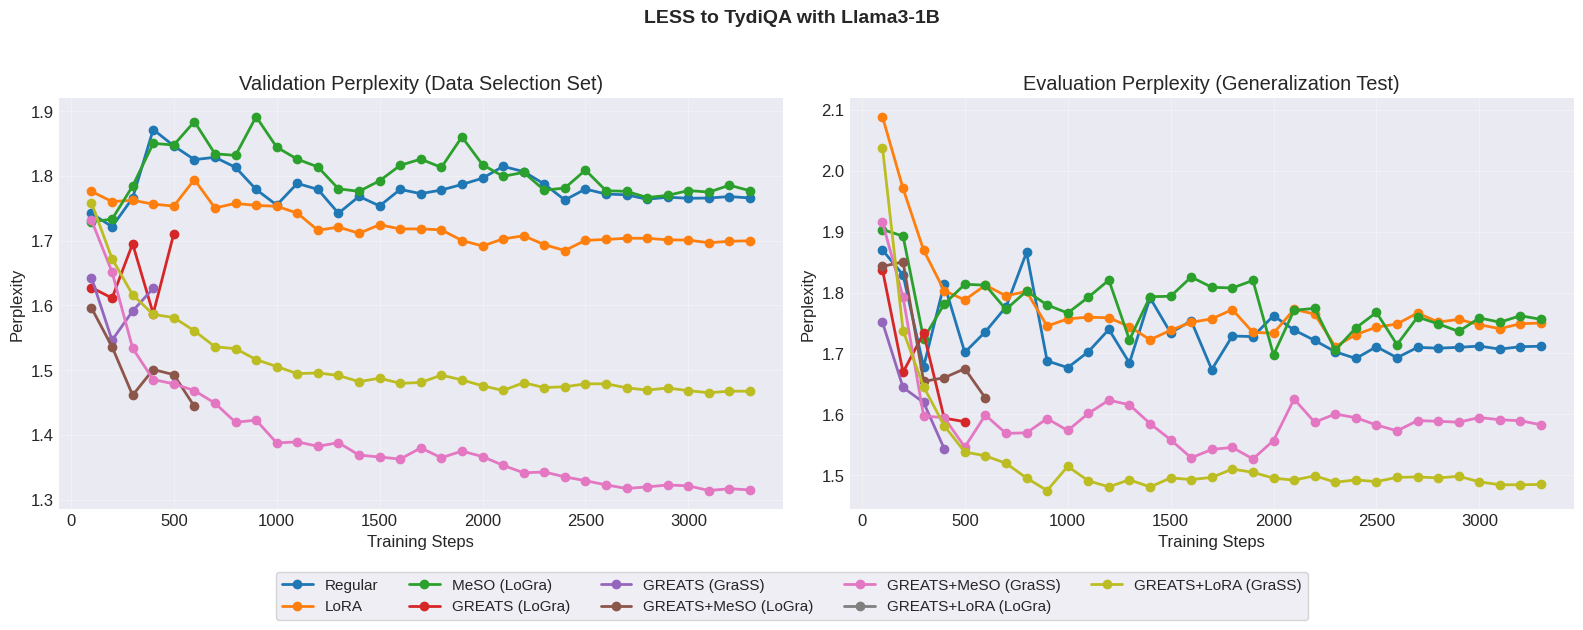

In [25]:
# Plotting configuration
max_steps = None  # Change to e.g., 100 to plot only first 100 steps
step_interval = None  # Change to e.g., 5 to plot every 5th step

if task == 'tydiqa':
    plot_title = f"LESS to TydiQA with {model.replace('_', ' ').title()}"
elif task == 'samsum':
    plot_title = f"ALPACA to SAMSUM with {model.replace('_', ' ').title()}"
else:
    plot_title = f"LESS to MMLU ({task.replace('_', ' ').title()}) with {model.replace('_', ' ').title()}"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Add main title
fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)

# Plot validation perplexity (small set for data selection)
ax = axes[0]
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        val_perp = data['val_perplexity'][mask]
    else:
        steps = data['steps']
        val_perp = data['val_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        val_perp = val_perp[indices]

    ax.plot(steps, val_perp, label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity (Data Selection Set)')
ax.grid(True, alpha=0.3)

# Plot evaluation perplexity (large held-out set)
ax = axes[1]
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        eval_perp = data['eval_perplexity'][mask]
    else:
        steps = data['steps']
        eval_perp = data['eval_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        eval_perp = eval_perp[indices]

    ax.plot(steps, eval_perp, label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Evaluation Perplexity (Generalization Test)')
ax.grid(True, alpha=0.3)

# Get handles and labels from one of the subplots (they're the same for both)
handles, labels = axes[0].get_legend_handles_labels()

# Create a single legend at the bottom of the figure
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=5, frameon=True, fontsize=11)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

## Plot Perplexity vs. Wall Time (Compute-Time Trade-off)

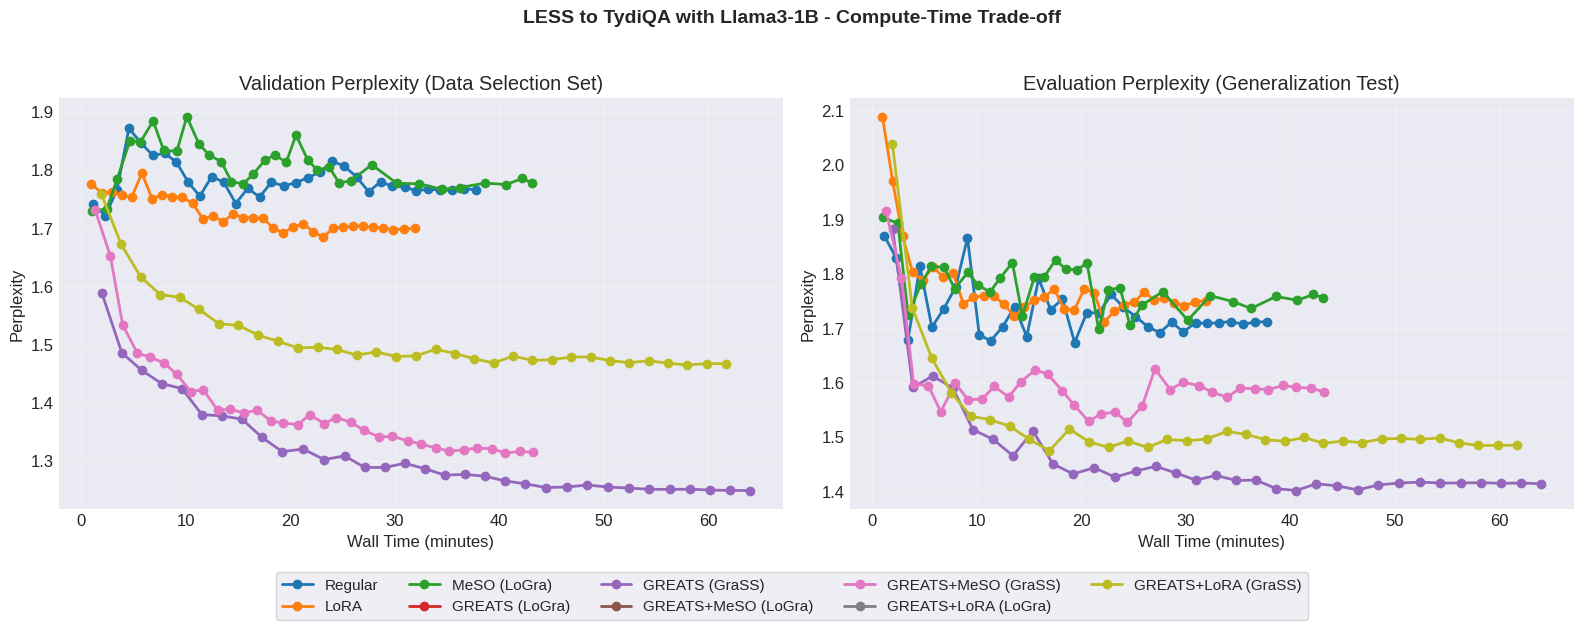

In [22]:
# Check if wall time data is available
has_wall_time = any(data['wall_time'] is not None for data in results.values())

if has_wall_time:
    # Plotting configuration
    max_wall_time = None  # Change to e.g., 3600 to plot only first hour (in seconds)

    if task == 'tydiqa':
        plot_title = f"LESS to TydiQA with {model.replace('_', ' ').title()} - Compute-Time Trade-off"
    elif task == 'samsum':
        plot_title = f"ALPACA to SAMSUM with {model.replace('_', ' ').title()} - Compute-Time Trade-off"
    else:
        plot_title = f"LESS to MMLU ({task.replace('_', ' ').title()}) with {model.replace('_', ' ').title()} - Compute-Time Trade-off"

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Add main title
    fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)

    # Plot validation perplexity vs. wall time
    ax = axes[0]
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            val_perp = data['val_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                val_perp = val_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            ax.plot(wall_time_minutes, val_perp, label=name, marker='o', linewidth=2)

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Validation Perplexity (Data Selection Set)')
    ax.grid(True, alpha=0.3)

    # Plot evaluation perplexity vs. wall time
    ax = axes[1]
    for name, data in results.items():
        if data['wall_time'] is not None:
            wall_time = data['wall_time']
            eval_perp = data['eval_perplexity']

            # Filter by max_wall_time if specified
            if max_wall_time is not None:
                mask = wall_time <= max_wall_time
                wall_time = wall_time[mask]
                eval_perp = eval_perp[mask]

            # Convert wall time to minutes for better readability
            wall_time_minutes = wall_time / 60.0
            ax.plot(wall_time_minutes, eval_perp, label=name, marker='o', linewidth=2)

    ax.set_xlabel('Wall Time (minutes)')
    ax.set_ylabel('Perplexity')
    ax.set_title('Evaluation Perplexity (Generalization Test)')
    ax.grid(True, alpha=0.3)

    # Get handles and labels from one of the subplots
    handles, labels = axes[0].get_legend_handles_labels()

    # Create a single legend at the bottom of the figure
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=5, frameon=True, fontsize=11)

    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()
else:
    print("Wall time data not available in the results.")
    print("Please re-run the training with the updated trainer to collect wall time data.")

## Compare Final Performance

In [ ]:
# Print final results
print("\n=== Final Perplexity Results ===")
print(f"{'Method':<20} {'Val Perplexity':<15} {'Eval Perplexity':<20}")
print("-" * 55)

for name, data in results.items():
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<20} {final_val:<15.4f} {final_eval:<15.4f}")


=== Final Perplexity Results ===
Method               Val Perplexity  Eval Perplexity     
-------------------------------------------------------
Regular              1.7349          1.7138         
LoRA                 1.7258          1.7652         
MeSO (LoGra)         1.7155          1.7810         
MeSO (GraSS)         1.7185          1.7693         
GREATS (LoGra)       1.5695          1.5650         
GREATS (GraSS)       1.3891          1.4578         
GREATS+MeSO (LoGra)  1.4155          1.5714         
GREATS+MeSO (GraSS)  1.5140          1.5750         
GREATS+LoRA (LoGra)  1.6342          1.6197         
GREATS+LoRA (GraSS)  1.6109          1.6187         


## Plot Improvement Over Baseline

In [ ]:
def load_accuracy_results(result_path):
    """Load accuracy results from evaluation output files."""
    if not Path(result_path).exists():
        return None

    with open(result_path, 'r') as f:
        data = json.load(f)

    return data

def build_accuracy_path(task, data_selection, optimizer, compressor, method_name, result_type):
    """Build the path for accuracy results."""
    config = experiment_configs.get((task, method_name))
    if config is None:
        return None

    batch_size, dataset_percentage, n_val, lr, seed, training_type = config
    setting = build_setting_str(batch_size, dataset_percentage, n_val, lr, seed, training_type)

    return f'{out_dir}/{task}-{data_selection}-{optimizer}-{compressor}-{setting}/{result_type}_results.json'

# Define paths for accuracy results based on the task
result_type = 'tydiqa' if task == 'tydiqa' else 'mmlu'

accuracy_experiments = {
    'Regular': build_accuracy_path(task, 'NA', 'Regular', 'NA', 'Regular', result_type),
    'GREATS (LoGra)': build_accuracy_path(task, 'GREATS', 'Regular', 'LoGra', 'GREATS (LoGra) LoRA', result_type),
    'GREATS (GraSS)': build_accuracy_path(task, 'GREATS', 'Regular', 'GraSS', 'GREATS (GraSS) LoRA', result_type),
}

# Filter out None values
accuracy_experiments = {k: v for k, v in accuracy_experiments.items() if v is not None}

# Load all accuracy results
accuracy_results = {}
for name, path in accuracy_experiments.items():
    result = load_accuracy_results(path)
    if result is not None:
        accuracy_results[name] = result
        print(f"Loaded accuracy results for {name}")
    else:
        print(f"Warning: {path} not found")

# Print accuracy results
if accuracy_results:
    print("\n" + "="*80)
    if task == 'tydiqa':
        print("=== TydiQA Evaluation Results ===")
        print("="*80)
        print(f"{'Method':<20} {'F1 Score':<15} {'Exact Match':<15} {'N_test':<10}")
        print("-"*80)

        for name, data in accuracy_results.items():
            f1 = data.get('f1_score', None)
            em = data.get('exact_match', None)
            n_test = data.get('n_test', 'N/A')

            # Format F1 score
            if isinstance(f1, (int, float)):
                f1_str = f"{f1:.2f}"
            else:
                f1_str = str(f1) if f1 is not None else 'N/A'

            # Format Exact Match
            if isinstance(em, (int, float)):
                em_str = f"{em:.2f}"
            else:
                em_str = str(em) if em is not None else 'N/A'

            print(f"{name:<20} {f1_str:<15} {em_str:<15} {n_test:<10}")
    else:
        print(f"=== MMLU Evaluation Results ({task.replace('_', ' ').title()}) ===")
        print("="*80)
        print(f"{'Method':<20} {'Accuracy (%)':<15} {'Correct/Total':<20}")
        print("-"*80)

        for name, data in accuracy_results.items():
            accuracy = data.get('accuracy', None)
            correct = data.get('num_correct', None)
            total = data.get('num_total', None)

            # Format accuracy
            if isinstance(accuracy, (int, float)):
                acc_str = f"{accuracy*100:.2f}"
            else:
                acc_str = str(accuracy) if accuracy is not None else 'N/A'

            # Format correct/total
            if correct is not None and total is not None:
                ct_str = f"{correct}/{total}"
            else:
                ct_str = 'N/A'

            print(f"{name:<20} {acc_str:<15} {ct_str:<20}")

    print("="*80)
else:
    print("\nNo accuracy results found. Please run the evaluation scripts first.")
    print(f"Expected paths:")
    for name, path in accuracy_experiments.items():
        print(f"  {name}: {path}")


No accuracy results found. Please run the evaluation scripts first.
Expected paths:
